<a href="https://colab.research.google.com/github/chhaya412/telco-customer-churn/blob/main/techno1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset shape:", df.shape)
display(df.head())
print(df.info())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Data quality check

In [2]:
print("Duplicate rows:", df.duplicated().sum())

print("Missing values before cleaning:")
print(df.isna().sum())

# Convert blank strings in TotalCharges to NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Duplicate rows: 0
Missing values before cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Missing TotalCharges: 11


Churn rate analyse

In [3]:
print(df["Churn"].value_counts())

churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Overall churn rate: 26.54%


Graphs
A. Contract type ke according churn

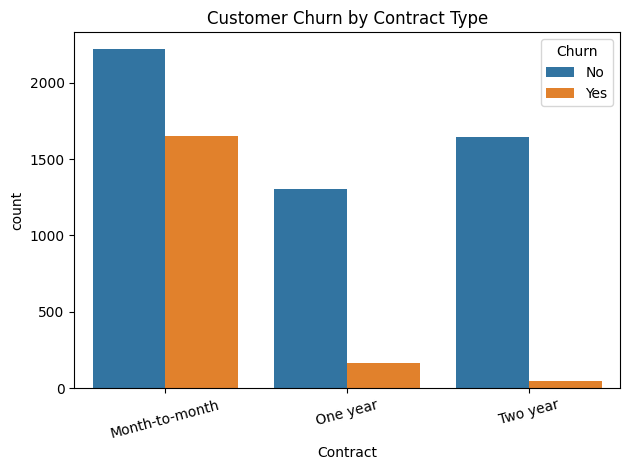

In [4]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Customer Churn by Contract Type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

B. Payment method ke according churn

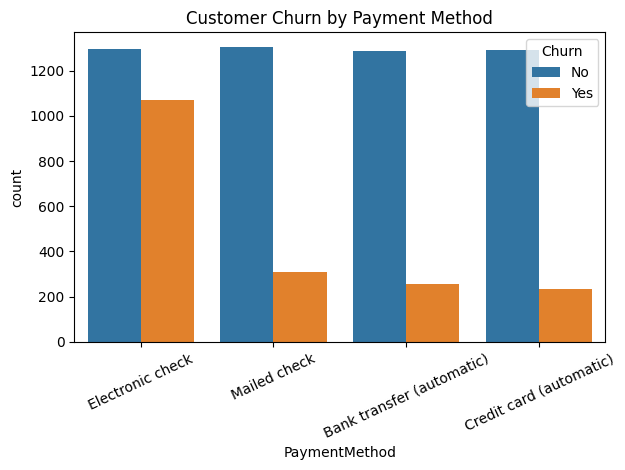

In [5]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Customer Churn by Payment Method")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

C. Tenure aur churn

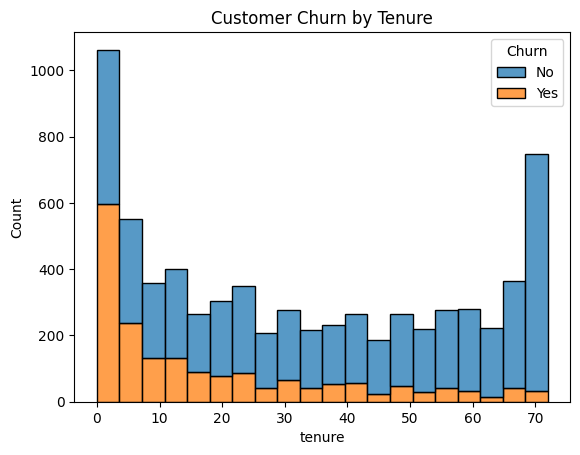

In [6]:
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=20,
    multiple="stack"
)
plt.title("Customer Churn by Tenure")
plt.show()